In [39]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt


## Problem 2.14

In [40]:
# Part a

# create arrays for latitude and solar declination angle
inc1 = 0.1
inc2 = .02
lat = np.arange(-90,90 + inc1, inc1) 
dec = np.arange(-23.28,23.28 + inc2, inc2)

# create a mesh grid of latitude and declination angle
LAT, DEC = np.meshgrid(lat, dec)

# use equation 2.77 to calculate zenith angle (complete calculation in radians and convert back to degrees)
zenith = (180/np.pi)*(np.arccos(np.cos(LAT*np.pi/180)*np.cos(DEC*np.pi/180)\
                                +np.sin(LAT*np.pi/180)*np.sin(DEC*np.pi/180)))
# zero out any unrealistic values (where zenith angle > 90 in the poles)
zenith_real = np.where(zenith <= 95, zenith, np.nan)


<ipython-input-40-ee5c4db55a0c>:13: RuntimeWarning: invalid value encountered in arccos
  zenith = (180/np.pi)*(np.arccos(np.cos(LAT*np.pi/180)*np.cos(DEC*np.pi/180)+np.sin(LAT*np.pi/180)*np.sin(DEC*np.pi/180)))


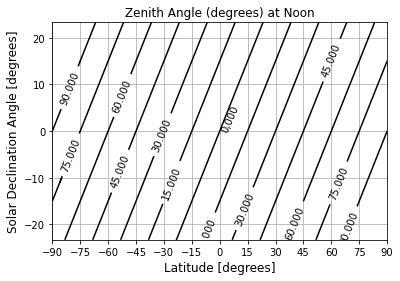

In [45]:
# create a contour plot of zenith angle
contours = plt.contour(LAT, DEC, zenith_real, colors='black')
plt.clabel(contours, levels = [0,15,30,45,60,75,90],inline=True, fontsize=10)
plt.title('Zenith Angle (degrees) at Noon', size=12) 
plt.xlabel('Latitude [degrees]', size=12)
plt.ylabel('Solar Declination Angle [degrees]', size=12)
plt.xlim(-90, 90), plt.ylim(-23.28, 23.28)

# only a few points along the zero line showed up in my calculations, so I am making the line darker
x1, y1 = [-23.28, 23.28], [-23.28, 23.28]
plt.plot(x1, y1, color = 'black')
plt.text(0,0,'0,000', rotation=66.5)
plt.xticks(np.arange(-90, 90+15, 15))
plt.grid()
plt.show()

In [57]:
# Part b

# create arrays for latitude and solar declination angle
inc1 = 0.1
inc2 = .02
lat = np.arange(-90,90 + inc1, inc1) 
dec = np.arange(-23.28,23.28 + inc2, inc2)

# create a mesh grid of latitude and declination angle
LAT, DEC = np.meshgrid(lat, dec)

# solve the rhs of the equation listed in the homework (complete calculation in radians and convert back to degrees)
# anywhere where this equation equals 90 solves our equation
rhs = (180/np.pi)*(np.arccos(np.cos(LAT*np.pi/180)*np.cos(np.pi/2)*np.cos(DEC*np.pi/180) \
                             + np.sin(LAT*np.pi/180)*np.sin(DEC*np.pi/180)))


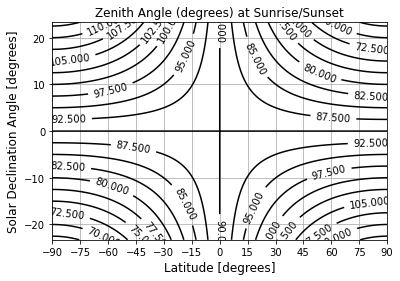

In [58]:
# create a contour plot of the rhs of the equation (anywhere where the contours=90 solves our equation)
contours = plt.contour(LAT, DEC, rhs, levels=20, colors='black')
plt.clabel(contours, inline=True, fontsize=10)
plt.title('Zenith Angle (degrees) at Sunrise/Sunset', size=12) 
plt.xlabel('Latitude [degrees]', size=12)
plt.ylabel('Solar Declination Angle [degrees]', size=12)
plt.xticks(np.arange(-90, 90+15, 15))
plt.grid()
plt.show()

## Problem 2.16

In [65]:
lat = 45*np.pi/180                        # latitude in radians
dec = 23.28*np.pi/180                     # solar declination angle in radians

hs = np.arccos(-np.tan(lat)*np.tan(dec))  # solve for h using the equation in my homework

Ro = 1366                                 # solar constant in W m^-2
omega = 2*np.pi                           # angular velocity of earth in rad/day

# calculate daily solar radiation
Q = (2*Ro/omega)*(np.cos(lat)*np.sin(hs)*np.cos(dec)+hs*np.sin(lat)*np.sin(dec))
print(Q)

499.8704655248652
